# Modelos de **boosting**

Mientras que los algoritmos de bagging y random forest entrenan múltiples árboles en paralelo, intentando reducir la varianza, los modelos de boosting siguen una lógica diferente y secuencial: entrenan árboles uno tras otro, y cada nuevo árbol intenta corregir los errores de los anteriores. El resultado es un modelo final de alta precisión, aunque más propenso a sobreajuste si no se controla.

A continuación, se va a mostrar como implementar dos de los algoritmos de boosting más populares, y compararemos su desempeño frente a un modelo de random forest.

In [ ]:
import pandas as pd

df = pd.read_csv(
    "http://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data",
    header=None,
    names=['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
           'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
           'hours-per-week', 'native-country', 'income'],
    na_values=' ?'
    )

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

X = df.drop(columns=['income'])
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1,
    stratify=y
    )

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.fit_transform(y_test)

print(X_train.shape)
print(X_test.shape)

(26048, 14)
(6513, 14)


No es necesario procesar valores nulos, pero si es necesario procesar las variables categóricas del dataset:

In [ ]:
from sklearn.preprocessing import (
    LabelEncoder,
    OrdinalEncoder,
    OneHotEncoder,
    TargetEncoder
    )
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

orden = [' Preschool', ' 1st-4th', ' 5th-6th', ' 7th-8th', ' 9th', ' 10th', ' 11th', ' 12th',
         ' HS-grad',' Some-college', ' Assoc-acdm', ' Assoc-voc', ' Bachelors', ' Masters',
         ' Prof-school', ' Doctorate']
ore = OrdinalEncoder(categories=[orden], dtype='int')
ohe = OneHotEncoder(sparse_output=False, drop='if_binary')
te = TargetEncoder()

preprocessor = ColumnTransformer(
    transformers=[
        ('cod_education', ore, ['education']),
        ('cod_oh', ohe, ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex']),
        ('cod_te', te, ['native-country'])
    ], remainder='passthrough')

Se sintoniza y entrena el modelo:

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, uniform

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=1))
])

dist = {
    'classifier__n_estimators':range(10, 200),
    'classifier__max_depth': range(3,5)
    }

random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=dist,
    scoring='f1_weighted',
    n_iter=20,
    random_state=1
    )

random_search.fit(X_train, y_train)

print(f'Best validation score: {random_search.best_score_:.3f} with parameters: {random_search.best_params_}')
print(f'Train score: {random_search.score(X_train, y_train):.3f}')
print(f'Test score: {random_search.score(X_test, y_test):.3f}')

Best validation score: 0.825 with parameters: {'classifier__n_estimators': 121, 'classifier__max_depth': 4}
Train score: 0.826
Test score: 0.820


Estas son las métricas del modelo:

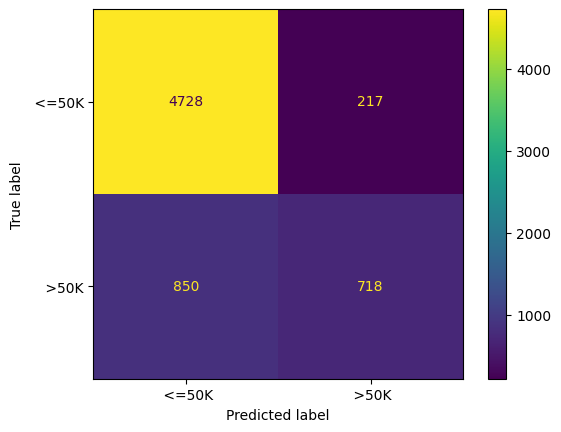

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    random_search.best_estimator_,
    X_test,
    y_test,
    display_labels=le.classes_
    );

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    random_search.best_estimator_.predict(X_test),
    target_names=le.classes_
    ))

              precision    recall  f1-score   support

       <=50K       0.85      0.96      0.90      4945
        >50K       0.77      0.46      0.57      1568

    accuracy                           0.84      6513
   macro avg       0.81      0.71      0.74      6513
weighted avg       0.83      0.84      0.82      6513



En la métrica de evaluación este modelo da buenos resultados, pero claramente está desbalanceado.

Se presenta la importancia relativa de las características del modelo:

In [ ]:
best_rf_model = random_search.best_estimator_
importances = best_rf_model.named_steps['classifier'].feature_importances_
features = best_rf_model.named_steps['preprocessor'].get_feature_names_out()

importances_df = pd.DataFrame({'Feature': features, 'Importance': importances})
#importances_df = importances_df[importances_df['Importance'] > 0]
importances_df.sort_values('Importance', ascending=False)

,Feature,Importance
12,cod_oh__marital-status_ Married-civ-spouse,0.187089
48,remainder__capital-gain,0.139233
47,remainder__education-num,0.129662
32,cod_oh__relationship_ Husband,0.129067
0,cod_education__education,0.089244
14,cod_oh__marital-status_ Never-married,0.085841
45,remainder__age,0.057371
50,remainder__hours-per-week,0.023525
49,remainder__capital-loss,0.023044
35,cod_oh__relationship_ Own-child,0.019677


## AdaBoost

AdaBoost fue el primer algoritmo de boosting exitoso. Su idea central es repesar las muestras:

- Se entrena un árbol débil (normalmente un «stump» o árbol de profundidad 1).
- Se identifican las muestras mal clasificadas.
- Se aumenta el peso de esas muestras difíciles y se reduce el de las bien clasificadas.
- El siguiente árbol se entrena enfocándose en esas muestras con mayor peso.
- Tras cada iteración, se asigna un alpha (importancia) al árbol según su precisión.

La predicción final es la suma ponderada de los predicciones de todos los árboles.

AdaBoost es excelente para clasificación binaria y robusto frente a sobreajuste.

Se va a empezar probando un modelo de AdaBoost sin sintonizar hiperparámetros.

Este modelo, y los modelos de boosting en general, no soporta valores nulos así que se deben procesar:

In [ ]:
df_dropna = df.dropna()

X = df_dropna.drop(columns=['income'])
y = df_dropna['income']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1,
    stratify=y
    )

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.fit_transform(y_test)

print(X_train.shape)
print(X_test.shape)

(24129, 14)
(6033, 14)


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import f1_score

ada = AdaBoostClassifier(
    n_estimators=50,
    random_state=1,
    )

ada_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', ada)
])

ada_model.fit(X_train, y_train)

train_score = f1_score(y_train, ada_model.predict(X_train), average='weighted')
test_score = f1_score(y_test, ada_model.predict(X_test), average='weighted')
print(f'Train score: {train_score:.3f}')
print(f'Test score: {test_score:.3f}')

Train score: 0.840
Test score: 0.841


Nótese como este modelo da mejores resultados que el random forest y no se sobreajusta, aún sin sintonización de hiperparámetros.

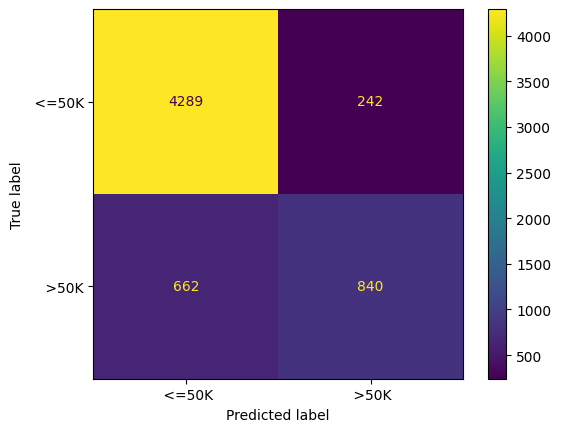

In [ ]:
ConfusionMatrixDisplay.from_estimator(ada_model, X_test, y_test, display_labels=le.classes_);

In [ ]:
print(classification_report(y_test, ada_model.predict(X_test), target_names=le.classes_))

              precision    recall  f1-score   support

       <=50K       0.87      0.95      0.90      4531
        >50K       0.78      0.56      0.65      1502

    accuracy                           0.85      6033
   macro avg       0.82      0.75      0.78      6033
weighted avg       0.84      0.85      0.84      6033



También se pueden obtener la importancia relativa de cada característica del modelo:

In [ ]:
importances = ada_model.named_steps['classifier'].feature_importances_
features = ada_model.named_steps['preprocessor'].get_feature_names_out()

importances_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importances_df = importances_df[importances_df['Importance'] > 0]
importances_df.sort_values('Importance', ascending=False)

,Feature,Importance
45,remainder__capital-gain,0.299552
10,cod_oh__marital-status_ Married-civ-spouse,0.220185
42,remainder__age,0.139727
44,remainder__education-num,0.090261
46,remainder__capital-loss,0.078168
47,remainder__hours-per-week,0.055164
0,cod_education__education,0.030747
18,cod_oh__occupation_ Exec-managerial,0.025909
32,cod_oh__relationship_ Own-child,0.020213
19,cod_oh__occupation_ Farming-fishing,0.015052


A la implementación en Scikit Learn de este algoritmo se le pueden sintonizar dos hiperparámetros: el número de estimadores y la tasa de aprendizaje, o `learning_rate`.

El `learning_rate` es un factor que ajusta la influencia de cada clasificador débil en la combinación final. Este parámetro se multiplica por el peso $\alpha$ de cada clasificador débil durante el proceso de agregación. Así:

- Si `learning_rate` es pequeño, cada clasificador tendrá un menor impacto en el modelo final, lo que puede reducir el riesgo de sobreajuste pero puede requerir más iteraciones para alcanzar un buen desempeño.
- Si `learning_rate` es grande, cada clasificador tendrá un mayor impacto en el modelo final, lo que puede llevar a un sobreajuste si no se tiene cuidado, ya que los clasificadores podrían aprender demasiado rápido y adaptarse demasiado a las particularidades de los datos de entrenamiento.

In [ ]:
dist = {
    'classifier__learning_rate':loguniform(1e-3, 10),
    'classifier__n_estimators': range(1, 200)}


random_search = RandomizedSearchCV(
    estimator=ada_model,
    param_distributions=dist,
    scoring='f1_weighted',
    n_iter=20,
    random_state=1
    )

random_search.fit(X_train, y_train)

print(f'Best validation score: {random_search.best_score_:.3f} with parameters: {random_search.best_params_}')
print(f'Train score: {random_search.score(X_train, y_train):.3f}')
print(f'Test score: {random_search.score(X_test, y_test):.3f}')

Best validation score: 0.846 with parameters: {'classifier__learning_rate': np.float64(1.6256611075126237), 'classifier__n_estimators': 62}
Train score: 0.847
Test score: 0.849


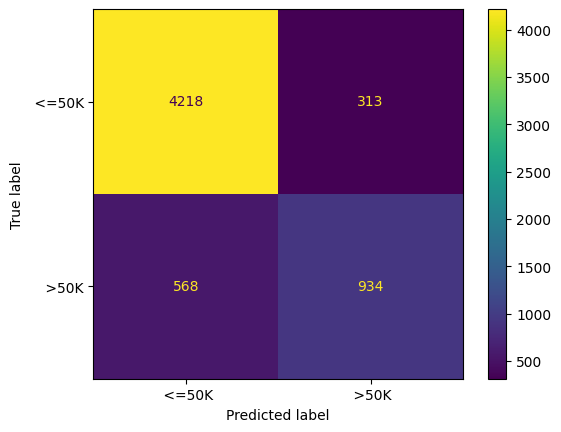

In [ ]:
ConfusionMatrixDisplay.from_estimator(
    random_search.best_estimator_,
    X_test,
    y_test,
    display_labels=le.classes_
    );

In [ ]:
print(classification_report(
    y_test,
    random_search.best_estimator_.predict(X_test),
    target_names=le.classes_
    ))

              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      4531
        >50K       0.75      0.62      0.68      1502

    accuracy                           0.85      6033
   macro avg       0.82      0.78      0.79      6033
weighted avg       0.85      0.85      0.85      6033



Este algoritmo entrega la importancia relativa de las características del modelo.

In [ ]:
best_ada_model = random_search.best_estimator_
importances = best_ada_model.named_steps['classifier'].feature_importances_
features = best_ada_model.named_steps['preprocessor'].get_feature_names_out()

importances_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importances_df = importances_df[importances_df['Importance'] > 0]
importances_df.sort_values('Importance', ascending=False)

,Feature,Importance
10,cod_oh__marital-status_ Married-civ-spouse,0.327429
45,remainder__capital-gain,0.133459
42,remainder__age,0.088904
0,cod_education__education,0.083024
44,remainder__education-num,0.070595
47,remainder__hours-per-week,0.059442
9,cod_oh__marital-status_ Married-AF-spouse,0.036079
46,remainder__capital-loss,0.028546
24,cod_oh__occupation_ Prof-specialty,0.025746
18,cod_oh__occupation_ Exec-managerial,0.019604


# Gradient Boosting

Gradient Boosting evoluciona la idea del boosting al tratar el proceso como un problema de **optimización de una función de pérdida**. La función de pérdida es MSE en los modelos de regresión y [log loss](https://scikit-learn.org/stable/modules/model_evaluation.html#log-loss) en los modelos de clasificación.

Así, en lugar de cambiar los pesos de los datos, cada nuevo árbol se entrena para predecir los **residuales** (el error o la diferencia entre el valor real y la predicción actual) del modelo previo.

Cada nuevo árbol es como un «parche» que minimiza una función de pérdida (error cuadrático, log-loss, etc.) usando el gradiente. El resultado final es:

$
\text{Predicción final} = \sum_{m=1}^{M} \eta \cdot (\text{árbol}_m)
$

Donde $\eta$ es la tasa de aprendizaje (learning rate), que controla la contribución de cada árbol.

Se va a entrenar un modelo  de gradient boosting con los parámetros por defecto:

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=50,
    max_depth=3,
    random_state=1)

gb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', gb)
])

gb_model.fit(X_train, y_train)

train_score = f1_score(y_train, gb_model.predict(X_train), average='weighted')
test_score = f1_score(y_test, gb_model.predict(X_test), average='weighted')
print(f'Train score: {train_score:.3f}')
print(f'Test score: {test_score:.3f}')

Train score: 0.850
Test score: 0.849


Nótese como este modelo da mejores resultados que los anteriores, y no se sobreajusta:

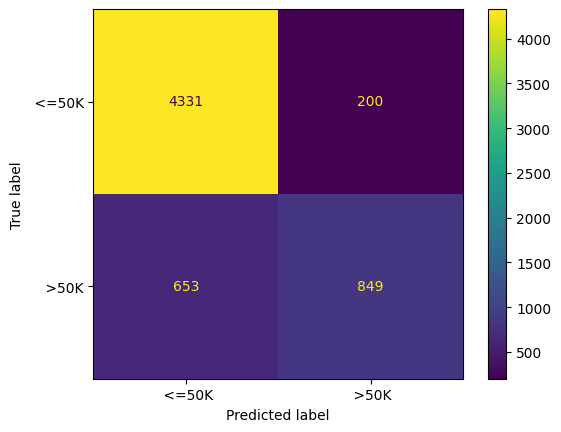

In [ ]:
ConfusionMatrixDisplay.from_estimator(
    gb_model,
    X_test,
    y_test,
    display_labels=le.classes_
    );

In [ ]:
print(classification_report(
    y_test,
    gb_model.predict(X_test),
    target_names=le.classes_
    ))

              precision    recall  f1-score   support

       <=50K       0.87      0.96      0.91      4531
        >50K       0.81      0.57      0.67      1502

    accuracy                           0.86      6033
   macro avg       0.84      0.76      0.79      6033
weighted avg       0.85      0.86      0.85      6033



Este modelo también calcula la importancia relativa de cada una de sus características:

In [ ]:
importances = gb_model.named_steps['classifier'].feature_importances_
features = gb_model.named_steps['preprocessor'].get_feature_names_out()

importances_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importances_df = importances_df[importances_df['Importance'] > 0]
importances_df.sort_values('Importance', ascending=False)

,Feature,Importance
10,cod_oh__marital-status_ Married-civ-spouse,0.397397
45,remainder__capital-gain,0.208332
44,remainder__education-num,0.107993
0,cod_education__education,0.098255
42,remainder__age,0.053264
46,remainder__capital-loss,0.052324
47,remainder__hours-per-week,0.031576
18,cod_oh__occupation_ Exec-managerial,0.019002
24,cod_oh__occupation_ Prof-specialty,0.008025
5,cod_oh__workclass_ Self-emp-not-inc,0.004370


En un modelo de **gradient boosting** se pueden ajustar varios **hiperparámetros** para optimizar su rendimiento. Además de los ya vistos en los árboles de decisión y los bosques aleatorios, estos hiperparámetros adicionales se pueden sintonizar:

* **learning_rate:** Controla el tamaño del paso que se da en la dirección del gradiente durante el entrenamiento. Un valor grande puede conducir a un entrenamiento más rápido, pero también puede aumentar el riesgo de sobreajuste.
* **Criterio de parada (n_iter_no_change, validation_fraction y tol):** Determina cuándo se detiene el entrenamiento del modelo. Se pueden utilizar diferentes criterios como un cierto nivel de precisión o una mejora mínima en la precisión.

Se va a entrenar un modelo de *gradient boosting* sintonizando algunos de estos hiperparámetros:

In [ ]:
dist = {
    'classifier__n_estimators':range(1, 201),
    'classifier__learning_rate':loguniform(1e-3,10),
    'classifier__min_samples_split':range(2,10)
    }

random_search = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=dist,
    random_state=1,
    scoring='f1_weighted',
    n_iter=20
    )

random_search.fit(X_train, y_train)

print(f'Best validation score: {random_search.best_score_:.3f} with parameters: {random_search.best_params_}')
print(f'Train score: {random_search.score(X_train, y_train):.3f}')
print(f'Test score: {random_search.score(X_test, y_test):.3f}')

Best validation score: 0.862 with parameters: {'classifier__learning_rate': np.float64(0.48597775414579947), 'classifier__min_samples_split': 3, 'classifier__n_estimators': 58}
Train score: 0.875
Test score: 0.865


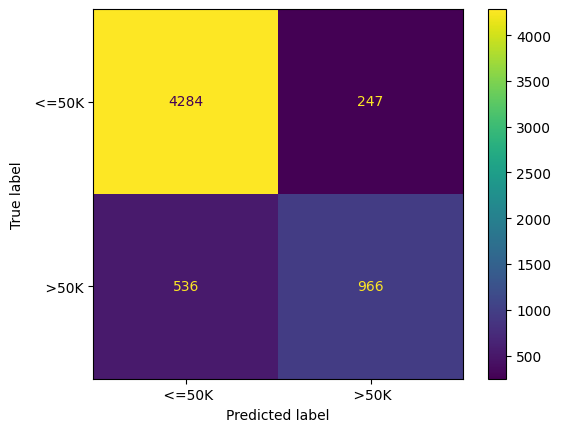

In [ ]:
ConfusionMatrixDisplay.from_estimator(
    random_search.best_estimator_,
    X_test,
    y_test,
    display_labels=le.classes_
    );

In [ ]:
print(classification_report(
    y_test,
    random_search.best_estimator_.predict(X_test),
    target_names=le.classes_
    ))

              precision    recall  f1-score   support

       <=50K       0.89      0.95      0.92      4531
        >50K       0.80      0.64      0.71      1502

    accuracy                           0.87      6033
   macro avg       0.84      0.79      0.81      6033
weighted avg       0.87      0.87      0.87      6033



El modelo mejora bastante y está menos desbalanceado.

In [ ]:
best_gb_model = random_search.best_estimator_
importances = best_gb_model.named_steps['classifier'].feature_importances_
features = best_gb_model.named_steps['preprocessor'].get_feature_names_out()

importances_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importances_df = importances_df[importances_df['Importance'] > 0]
importances_df.sort_values('Importance', ascending=False)

,Feature,Importance
10,cod_oh__marital-status_ Married-civ-spouse,0.373906
45,remainder__capital-gain,0.196624
44,remainder__education-num,0.138034
46,remainder__capital-loss,0.060406
42,remainder__age,0.057685
0,cod_education__education,0.053505
47,remainder__hours-per-week,0.035114
18,cod_oh__occupation_ Exec-managerial,0.017590
43,remainder__fnlwgt,0.009928
41,cod_te__native-country,0.006227
